# Time Series Analysis with AutoML

This notebook demonstrates **AutoML-based time series forecasting** using [AutoGluon](https://auto.gluon.ai/stable/tutorials/timeseries/index.html). AutoGluon automatically trains and compares multiple models from classical statistical methods to deep learning and combines the best ones into a weighted ensemble.

**What you will see:**
- How to wrap data into AutoGluon's `TimeSeriesDataFrame`
- How to configure and train a `TimeSeriesPredictor`
- How to compare model performance via the leaderboard
- How to generate and visualize multi-step forecasts

**When to use AutoML:**
- You need a strong baseline quickly without manually tuning individual models
- You want to benchmark multiple model families at once
- You have limited domain knowledge about which model class suits your data

> **Pitfall:** AutoML hides complexity but does not eliminate it. Always inspect the leaderboard, check that the inferred frequency is correct, and validate that the prediction horizon (`prediction_length`) matches your real use case.

In [1]:
import pandas as pd
from matplotlib import pyplot as plt
from autogluon.timeseries import TimeSeriesDataFrame, TimeSeriesPredictor

import warnings
warnings.filterwarnings("ignore")

## Load Data

We use the same DWD weather dataset, resampled to **weekly means**. The data is split at end of 2022, everything up to that point is used for training; the remaining ~2 years serve as the hold-out period we want to predict.

An `id_column` with a constant value is added because AutoGluon requires a panel-data format even for a single time series. Each row must belong to an identified series.

In [2]:
df = pd.read_csv("data/dwd_02932_climate.csv", sep=";", parse_dates=["date"], index_col="date")[["temperature_air_mean_2m", "precipitation_height", "pressure_vapor", "humidity"]].resample("W").mean()
df['id_column'] = 'weather'
df.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 2610 entries, 1975-01-05 to 2025-01-05
Freq: W-SUN
Data columns (total 5 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   temperature_air_mean_2m  2610 non-null   float64
 1   precipitation_height     2610 non-null   float64
 2   pressure_vapor           2610 non-null   float64
 3   humidity                 2610 non-null   float64
 4   id_column                2610 non-null   object 
dtypes: float64(4), object(1)
memory usage: 122.3+ KB


In [3]:
df.loc[:"2022"].tail()

,temperature_air_mean_2m,precipitation_height,pressure_vapor,humidity,id_column
date,,,,,
2022-11-27,3.614286,0.385714,7.185714,89.857143,weather
2022-12-04,1.714286,2.142857,6.385714,91.714286,weather
2022-12-11,0.600000,1.200000,5.885714,91.142857,weather
2022-12-18,-6.414286,0.000000,3.385714,88.285714,weather
2022-12-25,6.400000,3.642857,8.557143,86.857143,weather


### Create TimeSeriesDataFrame

`TimeSeriesDataFrame` is AutoGluon's internal container for time series data. It requires:
- A `timestamp_column` with regular datetime values
- An `id_column` identifying each individual series (required even for a single series)
- All remaining numeric columns are treated as the **target** or **covariates**

> **Pitfall:** AutoGluon distinguishes between *past covariates* (known only up to the forecast origin) and *known covariates* (available in the future). Features like precipitation are past covariates here, they are not known ahead of time and cannot be used to improve future predictions unless a separate forecast is provided for them.

In [4]:
train_data = TimeSeriesDataFrame.from_data_frame(
    df.loc[:"2022"].reset_index(),
    id_column="id_column",
    timestamp_column="date"
)
train_data.tail()

temperature_air_mean_2m  precipitation_height  \
item_id timestamp                                                   
weather 2022-11-27                 3.614286              0.385714   
        2022-12-04                 1.714286              2.142857   
        2022-12-11                 0.600000              1.200000   
        2022-12-18                -6.414286              0.000000   
        2022-12-25                 6.400000              3.642857   

                    pressure_vapor   humidity  
item_id timestamp                              
weather 2022-11-27        7.185714  89.857143  
        2022-12-04        6.385714  91.714286  
        2022-12-11        5.885714  91.142857  
        2022-12-18        3.385714  88.285714  
        2022-12-25        8.557143  86.857143

## Configure the Predictor

Key parameters:
- **`prediction_length`**: number of future steps to forecast. Here 104 = 2 years of weekly data. Choose this based on your actual forecasting horizon, setting it too large forces models to extrapolate far and degrades accuracy.
- **`target`**: the column to forecast, all other numeric columns become covariates.
- **`eval_metric`**: `MASE` (Mean Absolute Scaled Error) is scale-independent and handles seasonality well. It compares model error against a naive seasonal baseline, a score below 1.0 means the model beats the naive forecast.
- **`random_seed`**: fixes randomness for reproducibility across runs.

> **Pitfall:** The `path` argument determines where trained models are saved to disk. If you re-run without deleting this folder, AutoGluon will load cached models instead of retraining.

In [5]:
predictor = TimeSeriesPredictor(
    prediction_length=104,
    path="autogluon-weather-forecast",
    target="temperature_air_mean_2m",
    eval_metric="MASE",
)

## Train with AutoGluon

`predictor.fit()` trains all candidate models within the given `time_limit` and then fits a `WeightedEnsemble` on top. The `presets` parameter controls the trade-off between quality and speed:

| Preset | Models | Use case |
|---|---|---|
| `fast_training` | lightweight statistical and tree-based models only | quick baseline |
| `medium_quality` | models from fast + plus deep learning models | balanced |
| `high_quality` | mix of multiple DL, ML and statistical forecasting models | higher accuracy, longer training |
| `best_quality` | same as high + validation with multiple backtests | production |

**What happens internally:**
1. Models are trained sequentially, each receiving a time budget proportional to remaining time.
2. Validation is done on the last `prediction_length` steps of the training set (rolling window).
3. Models that exceed their time budget are skipped.
4. A `WeightedEnsemble` is fitted last, combining model predictions by minimizing validation error.

> **Pitfall:** Deep learning models (TFT, DeepAR, Chronos) dominate training time. With `time_limit=600`, simpler models finish in seconds while neural models may each consume 100+ seconds. If time is tight, use `presets="medium_quality"` or explicitly pass `hyperparameters` to restrict the model set.

In [ ]:
predictor.fit(
    train_data,
    presets="high_quality",
    time_limit=600,
)

## Leaderboard

The leaderboard ranks all trained models by their **validation score** (higher = better; scores are negated MASE, so closer to 0 is better). Key columns:
- `score_val`: validation MASE (negated). A value of −0.83 means MASE = 0.83, better than the seasonal naive baseline.
- `pred_time_val`: inference time in seconds, relevant for production latency constraints.
- `fit_time_marginal`: training time for that model alone.

**Reading the results:** The `WeightedEnsemble` typically wins or ties the best individual model. If a simple model like `DirectTabular` is close to the ensemble, the added complexity of deep learning may not be worth it for your use case.

> **Pitfall:** Leaderboard scores are evaluated on the *last* `prediction_length` steps of the training set, not on truly unseen data. Always validate on a separate hold-out set before drawing conclusions.

In [7]:
lb = predictor.leaderboard()
lb

,model,score_val,pred_time_val,fit_time_marginal,fit_order
0,WeightedEnsemble,-0.824970,2.146425,0.104096,11
1,TemporalFusionTransformer,-0.825672,0.010800,148.938367,9
2,DeepAR,-0.865048,0.172989,155.735153,10
3,Chronos2,-0.877642,0.213547,2.795569,5
4,Chronos2SmallFineTuned,-0.881442,0.230288,90.973722,6
5,ChronosWithRegressor[bolt_small],-0.891916,1.427880,0.007648,8
6,DirectTabular,-0.931786,0.022173,2.287695,3
7,RecursiveTabular,-1.360192,0.111924,1.868070,2
8,SeasonalNaive,-2.801248,1.094793,0.005369,1
9,AutoETS,-2.801624,1.748166,0.004440,7


## Generate Forecasts

`predictor.predict()` returns a `TimeSeriesDataFrame` with quantile forecasts (0.1–0.9) plus the `mean` prediction. Here we extract only the `mean` for the top 3 models from the leaderboard to compare them visually.

> **Pitfall:** `predictor.predict()` always forecasts the next `prediction_length` steps *after the last timestamp in the input data*. If you pass the full training set, forecasts start at 2023-01-01. Make sure your input data ends exactly where you want the forecast to begin.

In [8]:
predictions = {}
for model in lb["model"][:3]:
    predictions[model] = predictor.predict(train_data, model=model).to_data_frame().reset_index()[["timestamp", "mean"]].set_index("timestamp")

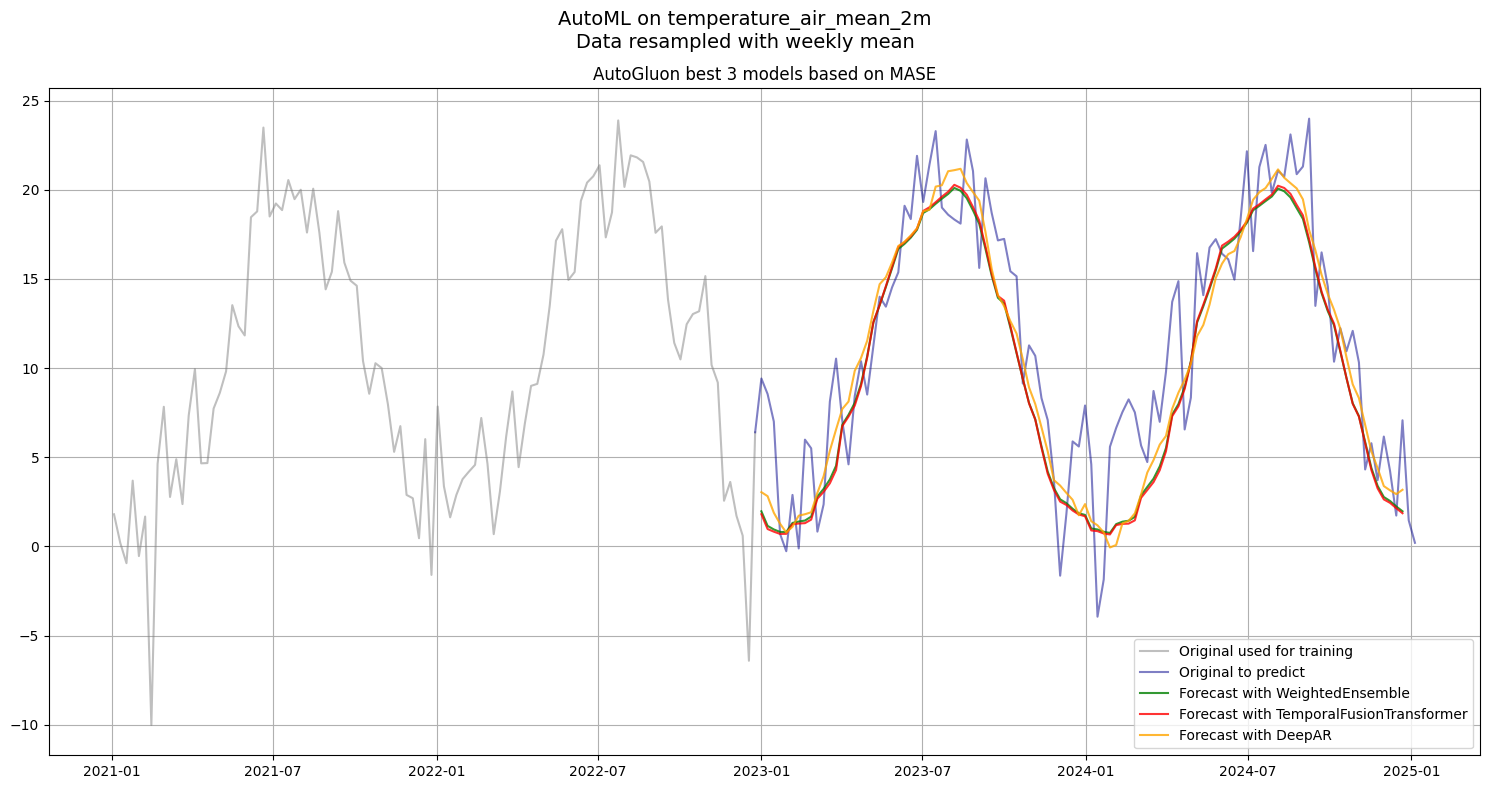

In [13]:
plt.figure(figsize=(15, 8))
plt.plot(df["temperature_air_mean_2m"].loc["2021":"2022"], label='Original used for training', color='grey', alpha=0.5)
plt.plot(df["temperature_air_mean_2m"].loc["2022-12-25":], label='Original to predict', color='darkblue', alpha=0.5)
for (model, pred), color in zip(predictions.items(), ['green', 'red', 'orange']):
    plt.plot(pred, label=f'Forecast with {model}', alpha=0.8, color=color)
plt.suptitle(f"AutoML on {df["temperature_air_mean_2m"].name}\nData resampled with weekly mean", fontsize=14)
plt.title("AutoGluon best 3 models based on MASE", fontsize=12)
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()